In [1]:
! pip install transformer_lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.3/566.3 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.4 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=73950c8a4532fbf7d72b3c4f84482e6a8addebe2

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# === Config ===
# RESULTS_DIR will be managed by the class

MODEL_NAMES = [
    # "gpt2-small",
    # "opt-125m",
    # "meta-llama/Llama-3.2-1B-Instruct",
    "gemma-2b-it"
]

# Prompts (changeable)
prompt_real = "What is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "What is the freezing point of water on Planet Xylon, where gravity is twice that of Earth?"

# Device / dtype configuration (use half precision on GPU to save memory)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Runtime config -> device={DEVICE}, dtype={DTYPE}")

class LogitLensAnalysis:
    """Performs logit lens uncertainty analysis for a given model and prompts."""

    def __init__(self, model_name, prompt_real, prompt_fake, device, dtype, results_dir="./results_logit_lens"):
        self.model_name = model_name
        self.prompt_real = prompt_real
        self.prompt_fake = prompt_fake
        self.device = device
        self.dtype = dtype
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        self.model = None  # Model will be loaded during analysis

    def _get_uncertainty_tokens(self):
        """Build a list of token ids corresponding to uncertainty/refusal words."""
        words = [
            "unknown", "unsure", "don", "'t", "know", "can't", "unable", "impossible",
            "doesn't", "exist", "fictional", "imaginary", "no", "such", "thing",
            "hypothetical", "made", "up", "never", "happened"
        ]
        ids = []
        for w in words:
            try:
                toks = self.model.to_tokens(" " + w, prepend_bos=False)[0]
                ids += toks.tolist()
            except Exception:
                # Some tokenizers may not produce tokens for certain unicode or forms
                pass
        # Remove duplicates
        ids = sorted(list(set(ids)))
        return ids

    def _mass_by_layer(self, prompt, token_ids):
        """Compute uncertainty mass per layer using logit lens on the last position."""
        # Cache only resid_post to reduce memory
        print(f"entering _mass_by_layer for prompt: '{prompt[:50]}...' ")
        logits, cache = self.model.run_with_cache(
            prompt,
            names_filter=lambda n: ("hook_resid_post" in n),
        )
        print(f"exiting _mass_by_layer")
        masses = []
        for layer in range(self.model.cfg.n_layers):
            resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1]  # [d_model]
            # Project through ln_final + unembed to get pseudo-logits
            try:
                pseudo_logits = self.model.unembed(self.model.ln_final(resid))  # [vocab]
            except Exception:
                # Fallback: some models may require different ordering; try unembed then ln_final
                pseudo_logits = self.model.ln_final(self.model.unembed(resid))
            probs = torch.softmax(pseudo_logits, dim=-1)
            masses.append(probs[token_ids].sum().item())
        return masses

    def _print_layerwise_table(self, layers, real_mass, fake_mass, out_txt=None):
      """Print (and optionally write) a descriptive table of layer-wise uncertainty masses."""
      delta = [f - r for f, r in zip(fake_mass, real_mass)]

      header = f"\nLayer-wise logit lens uncertainty mass ({self.model_name})\n"
      header += "Layer  |   Real Mass    |  Fake Mass    |   Delta\n"
      header += "------ | -------------- | ------------- | --------------"

      lines = [header]

      for l, r, f, d in zip(layers, real_mass, fake_mass, delta):
          lines.append(
              f"{l:>5}  | {r:>14.3e} | {f:>13.3e} | {d:>14.3e}"
          )

      table = "\n".join(lines)

      # Print to console
      print(table)

      # Optionally write to file
      if out_txt is not None:
          with open(out_txt, "w") as f:
              f.write(table + "\n")

    def _plot_logit_lens(self, layers, real_mass, fake_mass, out_path):
        plt.figure(figsize=(10, 6))
        plt.plot(layers, real_mass, label="Real prompt", marker="o", color="steelblue")
        plt.plot(layers, fake_mass, label="Fictional prompt", marker="o", color="coral")
        delta = [f - r for f, r in zip(fake_mass, real_mass)]
        plt.plot(layers, delta, label="Delta (fake - real)", linestyle="--", color="darkgreen")
        # Annotate max delta layer
        if len(delta) > 0:
            idx_max = max(range(len(delta)), key=lambda i: delta[i])
            plt.scatter([layers[idx_max]], [delta[idx_max]], color="darkgreen", zorder=3)
            plt.annotate(
                f"max Δ @ L{layers[idx_max]}\n{delta[idx_max]:.2e}",
                (layers[idx_max], delta[idx_max]),
                textcoords="offset points", xytext=(10, -10), ha="left",
                bbox=dict(boxstyle="round,pad=0.3", fc="#e8f5e9", ec="#2e7d32", alpha=0.8)
            )
        plt.xlabel("Layer")
        plt.ylabel("Uncertainty token mass (logit lens)")
        plt.title(
            f"Logit Lens Uncertainty vs Layer\n{self.model_name} — real vs fictional prompts",
        )
        plt.suptitle("Delta highlights where uncertainty begins to rise", fontsize=10, y=0.97)
        plt.grid(True, alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.show()
        plt.close()

    def run_analysis(self):
        """Executes the full logit lens analysis workflow for the initialized model."""
        print(f"\n{'='*60}")
        print(f"Processing model: {self.model_name}")
        print(f"{'='*60}")
        try:
            print(f"Loading {self.model_name}...")
            self.model = HookedTransformer.from_pretrained_no_processing(self.model_name, device=self.device, dtype=self.dtype)

            u_ids = self._get_uncertainty_tokens()
            print(f"Uncertainty token ids: {len(u_ids)} found")
            if not u_ids:
                print("Warning: No uncertainty tokens found; results may be uninformative.")

            print("Computing masses for real prompt...")
            real_mass = self._mass_by_layer(self.prompt_real, u_ids)

            print("Computing masses for fictional prompt...")
            fake_mass = self._mass_by_layer(self.prompt_fake, u_ids)

            layers = list(range(self.model.cfg.n_layers))
            model_dir = os.path.join(self.results_dir, self.model_name.replace("/", "_"))
            os.makedirs(model_dir, exist_ok=True)

            out_png = os.path.join(model_dir, "logit_lens_uncertainty_mass.png")

            print("Plotting and saving...")
            self._plot_logit_lens(layers, real_mass, fake_mass, out_png)
            self._print_layerwise_table(layers, real_mass, fake_mass, out_txt=os.path.join(model_dir, "logit_lens_uncertainty_mass.txt"))

            print(f"Saved plot: {out_png}")

        except Exception as e:
            print(f"Error processing {self.model_name}: {e}")
            import traceback
            traceback.print_exc()
        finally:
            # Free memory per model
            if self.model is not None:
                del self.model
                self.model = None # Clear reference
            torch.cuda.empty_cache() if torch.cuda.is_available() else None


Runtime config -> device=cuda, dtype=torch.float16



Processing model: gemma-2b-it
Loading gemma-2b-it...


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model gemma-2b-it into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water at standard at...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water on Planet Xylo...' 
exiting _mass_by_layer
Plotting and saving...


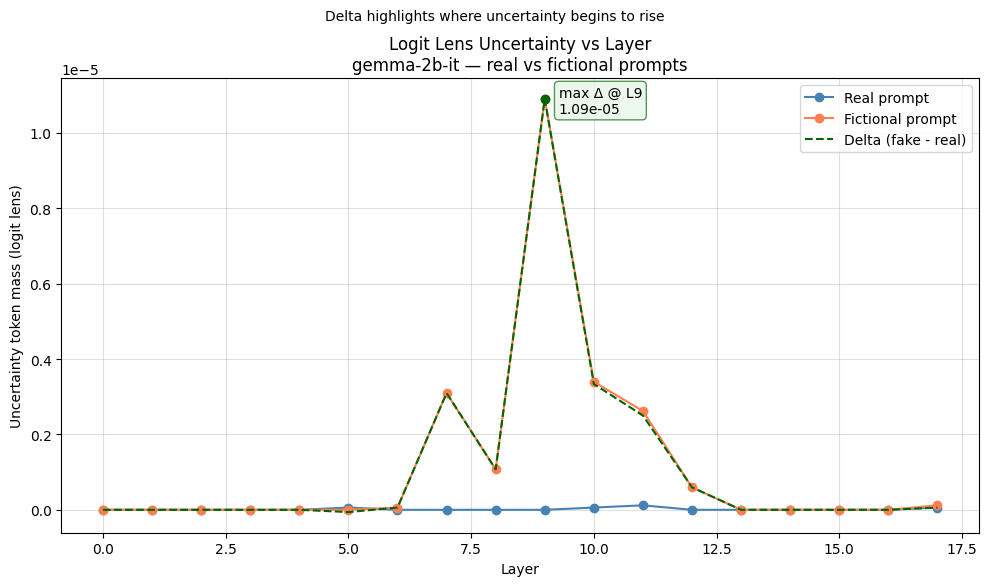


Layer-wise logit lens uncertainty mass (gemma-2b-it)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      0.000e+00 |     0.000e+00 |      0.000e+00
    2  |      0.000e+00 |     0.000e+00 |      0.000e+00
    3  |      0.000e+00 |     0.000e+00 |      0.000e+00
    4  |      0.000e+00 |     0.000e+00 |      0.000e+00
    5  |      5.960e-08 |     0.000e+00 |     -5.960e-08
    6  |      0.000e+00 |     5.960e-08 |      5.960e-08
    7  |      0.000e+00 |     3.099e-06 |      3.099e-06
    8  |      0.000e+00 |     1.073e-06 |      1.073e-06
    9  |      0.000e+00 |     1.091e-05 |      1.091e-05
   10  |      5.960e-08 |     3.397e-06 |      3.338e-06
   11  |      1.192e-07 |     2.623e-06 |      2.503e-06
   12  |      0.000e+00 |     5.960e-07 |      5.960e-07
   13  |      0.000e+00 |     0.000e+00 |      0.000e+00
   14  |      0.000e+00 |     0.000e+00 |

In [2]:
analyzer = LogitLensAnalysis(
    model_name="gemma-2b-it",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")

In [ ]:
!zip -r /content/results_logit_lens.zip /content/results_logit_lens/

updating: content/results_logit_lens/ (stored 0%)
updating: content/results_logit_lens/gpt2-small/ (stored 0%)
updating: content/results_logit_lens/gpt2-small/logit_lens_uncertainty_mass.txt (deflated 67%)
updating: content/results_logit_lens/gpt2-small/logit_lens_uncertainty_mass.png (deflated 13%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/ (stored 0%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/logit_lens_uncertainty_mass.txt (deflated 64%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/logit_lens_uncertainty_mass.png (deflated 11%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/ (stored 0%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/logit_lens_uncertainty_mass.txt (deflated 66%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/logit_lens_uncertainty_mass.png (deflated 10%)
  adding: content/results_logit_lens/qwen2.5-1.5b-instruct/ (stored 0%)
  adding: content/re


Processing model: gemma-2b
Loading gemma-2b...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model gemma-2b into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water at standard at...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water on Planet Xylo...' 
exiting _mass_by_layer
Plotting and saving...


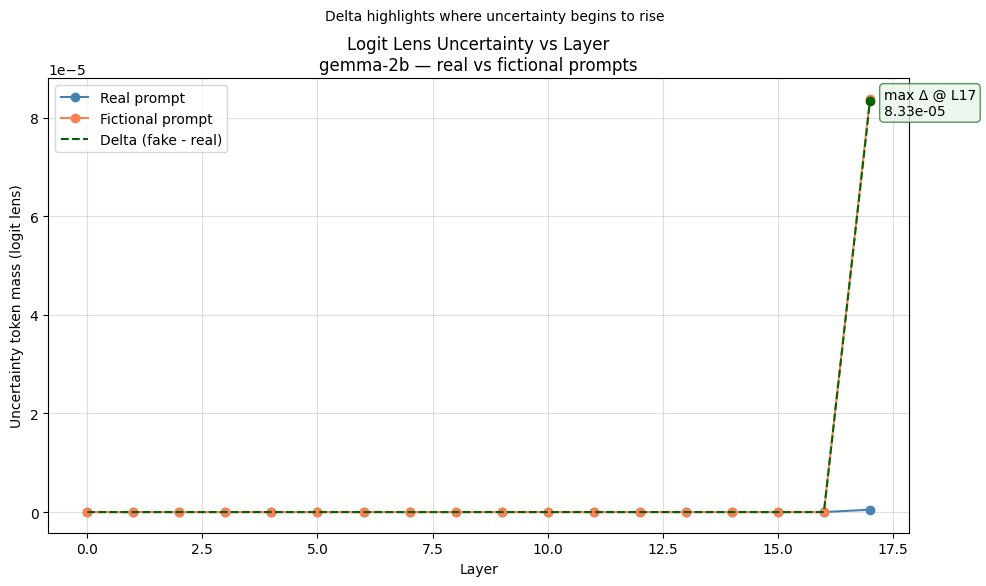


Layer-wise logit lens uncertainty mass (gemma-2b)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      0.000e+00 |     0.000e+00 |      0.000e+00
    2  |      0.000e+00 |     0.000e+00 |      0.000e+00
    3  |      0.000e+00 |     0.000e+00 |      0.000e+00
    4  |      0.000e+00 |     0.000e+00 |      0.000e+00
    5  |      0.000e+00 |     0.000e+00 |      0.000e+00
    6  |      0.000e+00 |     0.000e+00 |      0.000e+00
    7  |      0.000e+00 |     0.000e+00 |      0.000e+00
    8  |      0.000e+00 |     0.000e+00 |      0.000e+00
    9  |      0.000e+00 |     0.000e+00 |      0.000e+00
   10  |      0.000e+00 |     0.000e+00 |      0.000e+00
   11  |      0.000e+00 |     0.000e+00 |      0.000e+00
   12  |      0.000e+00 |     0.000e+00 |      0.000e+00
   13  |      0.000e+00 |     0.000e+00 |      0.000e+00
   14  |      0.000e+00 |     0.000e+00 |   

In [4]:
analyzer = LogitLensAnalysis(
    model_name="gemma-2b",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")